# Data Capstone: [Penyakit Tidak Menular]
- **Nama:** [Henokh William Christianos Lase]
- **Nama:** [Nicholas Howard Gouwtama]

##Pertanyaan Bisnis

1. Dapatkah kita memprediksi apakah seseorang berisiko terkena diabetes, hipertensi, kolesterol tinggi, stroke, atau penyakit jantung berdasarkan indikator gaya hidup dan kesehatan mereka?

2. Faktor gaya hidup apa (BMI, aktivitas fisik, pola makan, merokok, dll) yang paling kuat memprediksi masing-masing PTM?

3. Kelompok usia mana yang memiliki prevalensi tertinggi untuk tiap penyakit, dan kapan intervensi pencegahan paling kritis dilakukan?

4. Apakah terdapat pola komorbiditas — misalnya, seseorang yang menderita hipertensi juga cenderung menderita penyakit jantung?

5. Apakah seseorang yang rutin melakukan aktivitas fisik dan mengonsumsi buah/sayur memiliki risiko PTM yang secara signifikan lebih rendah?

6. Bagaimana dampak kebiasaan merokok dan konsumsi alkohol berat terhadap kemungkinan terkena stroke atau penyakit jantung?

7. Apakah ada perbedaan signifikan antara laki-laki dan perempuan dalam hal tingkat prevalensi dan faktor risiko PTM?


## Import Semua Packages/Library yang Digunakan

In [ ]:
!pip install iterative-stratification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
import warnings
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

**Tujuan**: Memuat dataset BRFSS 2015 ke dalam memori sebagai titik awal seluruh pipeline analisis.

**Insight**: Dataset ini merupakan data survei kesehatan perilaku masyarakat  yang berisi indikator kesehatan (BMI, pola makan, kebiasaan olahraga, dll) serta status 5 PTM utama. Output df.shape digunakan untuk verifikasi awal bahwa data berhasil dimuat dengan jumlah baris dan kolom yang diharapkan.


In [ ]:
file_path = 'sample_data/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

print(f"Total baris dan kolom: {df.shape}")
print("-" * 30)

display(df.head())

Total baris dan kolom: (253680, 22)
------------------------------


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Assessing Data

**Tujuan**: Audit kualitas data secara menyeluruh sebelum membersihkan apapun

**Insight**:
- Tipe data & missing values → memastikan tidak ada kolom yang salah tipe atau bernilai kosong
- Duplikat → data survei rentan entri ganda dari sistem pengumpulan data
- Statistik deskriptif → memahami distribusi awal dan rentang nilai wajar
- Outlier (IQR) → khusus untuk kolom kontinu (BMI, hari kesehatan mental/fisik buruk) karena nilai ekstrem dapat menyesatkan model ML. Outlier dilaporkan dalam jumlah dan persentase agar keputusan penanganan bisa dibuat berbasis data.



In [ ]:
print("--- Informasi Dasar Data ---")
df.info()
print("-" * 30)

print("\n--- Jumlah Missing Values per Kolom ---")
print(df.isna().sum())
print("-" * 30)

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Total baris duplikat: {jumlah_duplikat}")
print("-" * 30)

print("\n--- Ringkasan Statistik ---")
display(df.describe())

print("\n--- Indikasi Outlier pada Variabel Numerikal ---")
for col in ['BMI', 'MentHlth', 'PhysHlth']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}: batas bawah={lower:.1f}, batas atas={upper:.1f}, outlier={outlier:,} ({outlier/len(df)*100:.2f}%)")

--- Informasi Dasar Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               2

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000



--- Indikasi Outlier pada Variabel Numerikal ---
  BMI: batas bawah=13.5, batas atas=41.5, outlier=9,847 (3.88%)
  MentHlth: batas bawah=-3.0, batas atas=5.0, outlier=36,208 (14.27%)
  PhysHlth: batas bawah=-4.5, batas atas=7.5, outlier=40,949 (16.14%)


### Cleaning Data

**Tujuan**: Menghasilkan data bersih yang siap dianalisis dan dilatih ke model, tanpa distorsi dari duplikat maupun outlier ekstrem.

**Insight**:
- Hapus duplikat — dilakukan pertama karena outlier harus dihitung dari distribusi yang sudah bersih, bukan dari data yang berlebihan
- Winsorizing (IQR Cap) — dipilih daripada menghapus baris outlier karena dataset survei kesehatan sering memiliki nilai ekstrem yang valid secara medis (misal: BMI 60 memang ada). Winsorizing mempertahankan jumlah data sambil membatasi pengaruh nilai ekstrem. Output tabel rinci (min sebelum/sesudah, batas cap, jumlah baris yang terkena) memberikan transparansi penuh tentang perubahan yang dilakukan.



In [ ]:
df_clean = df.drop_duplicates()

print(f"Dimensi data awal              : {df.shape}")
print(f"Dimensi setelah hapus duplikat : {df_clean.shape}")
print(f"Sisa baris duplikat            : {df_clean.duplicated().sum()}")
print("-" * 45)

print("--- Penanganan Outlier dengan Winsorizing (IQR Cap) ---")
print(f"\n  {'Kolom':<12} {'Sebelum Min':>12} {'Sebelum Max':>12} "
      f"{'Cap Bawah':>10} {'Cap Atas':>10} {'Baris Di-cap':>13}")
print(f"  {'-'*73}")

kolom_outlier = ['BMI', 'MentHlth', 'PhysHlth']

for col in kolom_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    jumlah_sebelum_cap = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    min_sebelum = df_clean[col].min()   # ← fix: dari df_clean, bukan df
    max_sebelum = df_clean[col].max()   # ← fix: dari df_clean, bukan df

    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print(f"  {col:<12} "
          f"{min_sebelum:>12.1f} {max_sebelum:>12.1f} "
          f"{lower:>10.1f} {upper:>10.1f} "
          f"{jumlah_sebelum_cap:>10,} baris")

print(f"\n  ✓ Outlier berhasil di-cap ke batas IQR.")
print(f"  Dimensi akhir df_clean: {df_clean.shape}")

Dimensi data awal              : (253680, 22)
Dimensi setelah hapus duplikat : (229474, 22)
Sisa baris duplikat            : 0
---------------------------------------------
--- Penanganan Outlier dengan Winsorizing (IQR Cap) ---

  Kolom         Sebelum Min  Sebelum Max  Cap Bawah   Cap Atas  Baris Di-cap
  -------------------------------------------------------------------------
  BMI                  12.0         98.0       12.0       44.0      5,638 baris
  MentHlth              0.0         30.0       -3.0        5.0     36,162 baris
  PhysHlth              0.0         30.0       -6.0       10.0     34,346 baris

  ✓ Outlier berhasil di-cap ke batas IQR.
  Dimensi akhir df_clean: (229474, 22)


### Feature Selection

**Tujuan**: Mengeliminasi fitur yang tidak relevan atau berpotensi menimbulkan bias/kebocoran data (data leakage) agar model lebih generalisable.

**Insight**: Keempat kolom yang dihapus merepresentasikan faktor sosial-ekonomi dan akses layanan kesehatan yang bersifat hilir (downstream) — artinya, kolom-kolom ini lebih mencerminkan kondisi akses ke sistem kesehatan daripada faktor biologis/perilaku penyebab penyakit. Menyertakannya bisa membuat model bergantung pada proxy sosial-ekonomi alih-alih pola klinis yang sesungguhnya.


In [ ]:
columns_to_drop = ['AnyHealthcare', 'NoDocbcCost', 'Education', 'Income']

df_clean = df_clean.drop(columns=columns_to_drop)

print(f"Total baris dan kolom setelah penghapusan: {df_clean.shape}")
print("-" * 30)

print("Daftar kolom yang tersisa saat ini:")
print(df_clean.columns.tolist())

Total baris dan kolom setelah penghapusan: (229474, 18)
------------------------------
Daftar kolom yang tersisa saat ini:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age']


###Buat data_dashboard.csv yang bersih

**Tujuan**: Mengekspor data yang sudah bersih (tanpa duplikat, outlier sudah di-cap, fitur sudah diseleksi) sebagai single source of truth untuk keperluan visualisasi dashboard dan EDA lanjutan.

**Insight**: File ini dipisahkan dari proses ML karena >
- Dashboard/EDA membutuhkan data pada skala aslinya (sebelum normalisasi/SMOTE) agar grafik mudah diinterpretasi oleh stakeholder non-teknis
- Memisahkan artefak "untuk analisis" dan "untuk model" adalah praktik rekayasa data yang baik — mengubah data train untuk ML tidak akan merusak visualisasi yang sudah dibuat



In [ ]:
df_clean.to_csv('data_dashboard.csv', index=False)
print(f"✓ data_dashboard.csv siap!")
print(f"  Baris  : {df_clean.shape[0]:,}")
print(f"  Kolom  : {df_clean.shape[1]}")
print(f"  Kolom  : {df_clean.columns.tolist()}")

✓ data_dashboard.csv siap!
  Baris  : 229,474
  Kolom  : 18
  Kolom  : ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age']


## EDA

### Persiapan Variabel EDA

**Tujuan**: Mendefinisikan kamus dan daftar variabel yang akan digunakan secara konsisten
di seluruh proses EDA, agar kode lebih rapi, mudah dibaca, dan tidak perlu menulis
ulang nama kolom berulang kali.

**Insight**:
- `kolom_penyakit` → 5 target label PTM yang menjadi fokus analisis: Diabetes, Hipertensi,
  Kolesterol Tinggi, Stroke, dan Penyakit Jantung
- `kolom_faktor` → 13 variabel prediktor yang mencakup faktor gaya hidup (olahraga, pola makan,
  merokok) dan kondisi klinis (BMI, kesehatan umum, hari sakit)
- `kolom_faktor_binary` → subset 8 variabel bertipe 0/1 (Ya/Tidak)
- `kolom_faktor_numerikal` → subset 5 variabel kontinu dengan rentang nilai lebih luas
- `label_faktor` → mapping nama teknis ke label yang lebih mudah dibaca untuk visualisasi

In [ ]:
  kolom_penyakit = {
    'Diabetes_binary': 'Diabetes',
    'HighBP': 'Hipertensi (Tekanan Darah Tinggi)',
    'HighChol': 'Kolesterol Tinggi',
    'Stroke': 'Stroke',
    'HeartDiseaseorAttack': 'Penyakit Jantung / Serangan Jantung'
}

kolom_faktor = ['CholCheck', 'BMI', 'Smoker', 'PhysActivity', 'Fruits',
                'Veggies', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth',
                'PhysHlth', 'DiffWalk', 'Sex', 'Age']

kolom_faktor_binary = ['CholCheck', 'Smoker', 'PhysActivity', 'Fruits',
                       'Veggies', 'HvyAlcoholConsump', 'DiffWalk', 'Sex']

kolom_faktor_numerikal = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']

label_faktor = {
    'CholCheck'         : 'Cek Kolesterol (5 thn terakhir)',
    'BMI'               : 'Indeks Massa Tubuh (BMI)',
    'Smoker'            : 'Perokok (>=100 batang seumur hidup)',
    'PhysActivity'      : 'Aktif Fisik/Olahraga (30 hari terakhir)',
    'Fruits'            : 'Konsumsi Buah Harian',
    'Veggies'           : 'Konsumsi Sayur Harian',
    'HvyAlcoholConsump' : 'Konsumsi Alkohol Berat',
    'GenHlth'           : 'Kondisi Kesehatan Umum (1=baik, 5=buruk)',
    'MentHlth'          : 'Hari Kesehatan Mental Buruk (30 hari)',
    'PhysHlth'          : 'Hari Kesehatan Fisik Buruk (30 hari)',
    'DiffWalk'          : 'Kesulitan Berjalan/Naik Tangga',
    'Sex'               : 'Jenis Kelamin (0=Perempuan, 1=Laki-laki)',
    'Age'               : 'Kelompok Usia (1=18-24 s.d 13=80+)'
}

print("=" * 60)
print("EDA UNIVARIATE")
print("=" * 60)

print("\n--- Distribusi 5 Penyakit Utama ---")
for col, nama in kolom_penyakit.items():
    counts = df_clean[col].value_counts().sort_index()
    total = counts.sum()
    print(f"\n  {nama}:")
    for val, count in counts.items():
        pct = count / total * 100
        label = 'Tidak' if val == 0.0 else 'Ya   '
        print(f"    {label} : {count:>7,} ({pct:5.1f}%)")

print("\n--- Statistik Deskriptif Faktor Numerikal ---")
print(f"\n  {'Faktor':<40} {'Min':>6} {'Rata2':>7} {'Median':>8} {'Max':>6}")
print(f"  {'-'*70}")
for col in kolom_faktor_numerikal:
    mn  = df_clean[col].min()
    avg = df_clean[col].mean()
    med = df_clean[col].median()
    mx  = df_clean[col].max()
    print(f"  {label_faktor[col]:<40} {mn:>6.1f} {avg:>7.2f} {med:>8.1f} {mx:>6.1f}")

print("\n--- Distribusi Faktor Binary ---")
for col in kolom_faktor_binary:
    counts = df_clean[col].value_counts().sort_index()
    total = counts.sum()
    print(f"\n  {label_faktor[col]}:")
    for val, count in counts.items():
        pct = count / total * 100
        label = 'Tidak' if val == 0.0 else 'Ya   '
        print(f"    {label} : {count:>7,} ({pct:5.1f}%)")

EDA UNIVARIATE

--- Distribusi 5 Penyakit Utama ---

  Diabetes:
    Tidak : 194,377 ( 84.7%)
    Ya    :  35,097 ( 15.3%)

  Hipertensi (Tekanan Darah Tinggi):
    Tidak : 125,214 ( 54.6%)
    Ya    : 104,260 ( 45.4%)

  Kolesterol Tinggi:
    Tidak : 128,129 ( 55.8%)
    Ya    : 101,345 ( 44.2%)

  Stroke:
    Tidak : 219,190 ( 95.5%)
    Ya    :  10,284 (  4.5%)

  Penyakit Jantung / Serangan Jantung:
    Tidak : 205,761 ( 89.7%)
    Ya    :  23,713 ( 10.3%)

--- Statistik Deskriptif Faktor Numerikal ---

  Faktor                                      Min   Rata2   Median    Max
  ----------------------------------------------------------------------
  Indeks Massa Tubuh (BMI)                   12.0   28.47     27.0   44.0
  Kondisi Kesehatan Umum (1=baik, 5=buruk)    1.0    2.60      3.0    5.0
  Hari Kesehatan Mental Buruk (30 hari)       0.0    1.29      0.0    5.0
  Hari Kesehatan Fisik Buruk (30 hari)        0.0    2.48      0.0   10.0
  Kelompok Usia (1=18-24 s.d 13=80+)       

### EDA Multivariate — Korelasi Faktor Risiko terhadap 5 PTM

**Tujuan**: Mengukur kekuatan dan arah hubungan linear antara setiap faktor kesehatan
dengan masing-masing penyakit, sehingga kita bisa mengidentifikasi faktor mana yang
paling signifikan sebagai prediktor.

**Insight**:
- **Faktor Risiko (korelasi positif ≥ 0.03)** → semakin tinggi nilainya, semakin besar
  kemungkinan seseorang menderita penyakit tersebut. Contoh: GenHlth dan BMI tinggi
  konsisten menjadi faktor risiko di hampir semua PTM.
- **Faktor Pelindung (korelasi negatif)** → semakin tinggi nilainya, semakin kecil risiko
  penyakit. Contoh: PhysActivity dan konsumsi buah/sayur cenderung bersifat protektif.
- Threshold 0.03 digunakan karena korelasi pada data survei berskala besar cenderung kecil
  secara absolut namun tetap bermakna secara statistik.
- Pola korelasi yang konsisten di semua 5 penyakit mengindikasikan adanya **faktor risiko
  universal** yang penting untuk intervensi kesehatan masyarakat.

In [ ]:
print("=" * 60)
print("EDA MULTIVARIATE")
print("=" * 60)

print("\n--- Korelasi Faktor Penyebab terhadap 5 Penyakit ---")
for col, nama in kolom_penyakit.items():
    corr = df_clean[kolom_faktor].corrwith(df_clean[col]).sort_values(ascending=False)
    print(f"\n  {nama}:")
    print(f"  Faktor Risiko (meningkatkan kemungkinan sakit):")
    for faktor, val in corr[corr >= 0.03].items():
        print(f"    ↑ {label_faktor[faktor]:<40} : +{val:.4f}")
    print(f"  Faktor Pelindung (menurunkan kemungkinan sakit):")
    for faktor, val in corr[corr < 0].items():
        print(f"    ↓ {label_faktor[faktor]:<40} : {val:.4f}")

print("\n--- Korelasi Antar 5 Penyakit Utama ---")
corr_penyakit = df_clean[list(kolom_penyakit.keys())].corr().round(3)
corr_penyakit.index = list(kolom_penyakit.values())
corr_penyakit.columns = list(kolom_penyakit.values())
print(corr_penyakit.to_string())

EDA MULTIVARIATE

--- Korelasi Faktor Penyebab terhadap 5 Penyakit ---

  Diabetes:
  Faktor Risiko (meningkatkan kemungkinan sakit):
    ↑ Kondisi Kesehatan Umum (1=baik, 5=buruk) : +0.2769
    ↑ Indeks Massa Tubuh (BMI)                 : +0.2233
    ↑ Kesulitan Berjalan/Naik Tangga           : +0.2053
    ↑ Kelompok Usia (1=18-24 s.d 13=80+)       : +0.1773
    ↑ Hari Kesehatan Fisik Buruk (30 hari)     : +0.1535
    ↑ Cek Kolesterol (5 thn terakhir)          : +0.0725
    ↑ Perokok (>=100 batang seumur hidup)      : +0.0455
    ↑ Jenis Kelamin (0=Perempuan, 1=Laki-laki) : +0.0327
  Faktor Pelindung (menurunkan kemungkinan sakit):
    ↓ Konsumsi Buah Harian                     : -0.0248
    ↓ Konsumsi Sayur Harian                    : -0.0417
    ↓ Konsumsi Alkohol Berat                   : -0.0660
    ↓ Aktif Fisik/Olahraga (30 hari terakhir)  : -0.1004

  Hipertensi (Tekanan Darah Tinggi):
  Faktor Risiko (meningkatkan kemungkinan sakit):
    ↑ Kelompok Usia (1=18-24 s.d 13=80+)   

### EDA Kategorikal & Numerikal — Rata-rata Faktor per Status Penyakit

**Tujuan**: Membandingkan nilai rata-rata setiap faktor numerikal antara kelompok
"Tidak Sakit" dan "Sakit" untuk masing-masing PTM.

**Insight**:
- Kolom **Selisih** menunjukkan besar perbedaan rata-rata — semakin besar selisihnya,
  semakin kuat faktor tersebut membedakan kelompok sakit dan tidak sakit.
- **BMI**: Rata-rata BMI kelompok "Sakit" konsisten lebih tinggi untuk semua PTM.
- **GenHlth**: Kelompok "Sakit" memiliki rata-rata GenHlth jauh lebih tinggi —
  penyakit PTM sangat berkorelasi dengan persepsi kesehatan diri yang buruk.
- **MentHlth & PhysHlth**: Kelompok "Sakit" melaporkan lebih banyak hari dengan
  kesehatan mental dan fisik yang buruk.
- **Age**: Rata-rata kelompok usia "Sakit" lebih tinggi untuk semua PTM — menegaskan
  bahwa PTM prevalensinya meningkat seiring bertambahnya usia.

In [ ]:
print("=" * 60)
print("EDA KATEGORIKAL & NUMERIKAL")
print("=" * 60)

print("\n--- Rata-rata Faktor Numerikal per Penyakit ---")
for col, nama in kolom_penyakit.items():
    print(f"\n  {nama}:")
    print(f"  {'Faktor':<40} {'Tidak Sakit':>12} {'Sakit':>8} {'Selisih':>9} {'Ket':>15}")
    print(f"  {'-'*85}")
    for faktor in kolom_faktor_numerikal:
        stats = df_clean.groupby(col)[faktor].mean().round(2)
        tidak = stats[0.0]
        ya    = stats[1.0]
        diff  = ya - tidak
        arah  = "↑ lebih tinggi" if diff > 0 else "↓ lebih rendah"
        print(f"  {label_faktor[faktor]:<40} {tidak:>12.2f} {ya:>8.2f} {abs(diff):>9.2f} {arah:>15}")

print("\n--- Proporsi Faktor Binary per Penyakit ---")
for col, nama in kolom_penyakit.items():
    print(f"\n  {nama}:")
    print(f"  {'Faktor':<40} {'Tidak Sakit':>12} {'Sakit':>8} {'Selisih':>9}")
    print(f"  {'-'*72}")
    for faktor in kolom_faktor_binary:
        props = df_clean.groupby(col)[faktor].mean() * 100
        diff  = props[1.0] - props[0.0]
        arah  = "↑" if diff > 0 else "↓"
        print(f"  {label_faktor[faktor]:<40} {props[0.0]:>11.1f}% {props[1.0]:>7.1f}% {arah}{abs(diff):>7.1f}%")

print("\n--- Distribusi Kelompok Usia per Penyakit ---")
usia_label = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}
for col, nama in kolom_penyakit.items():
    print(f"\n  {nama}:")
    ct = df_clean.groupby(['Age', col]).size().unstack(fill_value=0)
    ct.columns = ['Tidak Sakit', 'Sakit']
    ct['Total']   = ct.sum(axis=1)
    ct['% Sakit'] = (ct['Sakit'] / ct['Total'] * 100).round(1)
    print(f"  {'Usia':>8} {'Tidak Sakit':>12} {'Sakit':>8} {'Total':>8} {'% Sakit':>9}")
    print(f"  {'-'*50}")
    for idx, row in ct.iterrows():
        usia = usia_label.get(int(idx), str(int(idx)))
        print(f"  {usia:>8} {row['Tidak Sakit']:>12,} {row['Sakit']:>8,} {row['Total']:>8,} {row['% Sakit']:>8.1f}%")

EDA KATEGORIKAL & NUMERIKAL

--- Rata-rata Faktor Numerikal per Penyakit ---

  Diabetes:
  Faktor                                    Tidak Sakit    Sakit   Selisih             Ket
  -------------------------------------------------------------------------------------
  Indeks Massa Tubuh (BMI)                        27.91    31.56      3.65  ↑ lebih tinggi
  Kondisi Kesehatan Umum (1=baik, 5=buruk)         2.48     3.30      0.82  ↑ lebih tinggi
  Hari Kesehatan Mental Buruk (30 hari)            1.27     1.41      0.14  ↑ lebih tinggi
  Hari Kesehatan Fisik Buruk (30 hari)             2.23     3.85      1.62  ↑ lebih tinggi
  Kelompok Usia (1=18-24 s.d 13=80+)               7.85     9.38      1.53  ↑ lebih tinggi

  Hipertensi (Tekanan Darah Tinggi):
  Faktor                                    Tidak Sakit    Sakit   Selisih             Ket
  -------------------------------------------------------------------------------------
  Indeks Massa Tubuh (BMI)                        27.31    

### Train-Test Split — Multilabel Stratified Split

**Tujuan**: Membagi data menjadi set pelatihan (80%) dan pengujian (20%) dengan memastikan
distribusi proporsi setiap label penyakit tetap seimbang di kedua set.

**Insight**:
- Digunakan `MultilabelStratifiedShuffleSplit` bukan `train_test_split` biasa karena
  kita memiliki **5 label target sekaligus** (multilabel).
- Rasio 80:20 adalah standar industri yang memberikan cukup data untuk training
  sekaligus mempertahankan set evaluasi yang representatif.
- `random_state=42` memastikan split dapat direproduksi — siapapun yang menjalankan
  kode ini akan mendapat split yang sama persis.

In [ ]:
X = df_clean.drop(columns=list(kolom_penyakit.keys()))
y = df_clean[list(kolom_penyakit.keys())]

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(msss.split(X, y))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test  = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test  = y.iloc[test_idx].reset_index(drop=True)

print("--- Verifikasi Train-Test Split ---")
print(f"  Total data    : {len(df_clean):>7,} baris")
print(f"  Data train    : {len(X_train):>7,} baris ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"  Data test     : {len(X_test):>7,} baris ({len(X_test)/len(df_clean)*100:.1f}%)")
print(f"\n  Jumlah fitur  : {X_train.shape[1]} kolom")
print(f"  Jumlah target : {y_train.shape[1]} kolom")

print("\n--- Distribusi Label (% positif) ---")
print(f"  {'Label':<30} {'Train':>8} {'Test':>8}")
print(f"  {'-'*48}")
for col, nama in kolom_penyakit.items():
    tr = y_train[col].mean() * 100
    te = y_test[col].mean()  * 100
    print(f"  {nama:<30} {tr:>7.1f}% {te:>7.1f}%")

--- Verifikasi Train-Test Split ---
  Total data    : 229,474 baris
  Data train    : 183,579 baris (80.0%)
  Data test     :  45,895 baris (20.0%)

  Jumlah fitur  : 13 kolom
  Jumlah target : 5 kolom

--- Distribusi Label (% positif) ---
  Label                             Train     Test
  ------------------------------------------------
  Diabetes                          15.3%    15.3%
  Hipertensi (Tekanan Darah Tinggi)    45.4%    45.4%
  Kolesterol Tinggi                 44.2%    44.2%
  Stroke                             4.5%     4.5%
  Penyakit Jantung / Serangan Jantung    10.3%    10.3%


### Preprocessing — MinMaxScaler

**Tujuan**: Menormalisasi 5 kolom numerikal ke rentang [0, 1] agar algoritma ML
yang sensitif terhadap skala tidak didominasi oleh fitur dengan nilai absolut besar.

**Insight**:
- Dipilih `MinMaxScaler` karena distribusi variabel tidak mengikuti distribusi normal
  sempurna, dan hasilnya lebih intuitif (0 = minimum, 1 = maksimum dalam data train).
- **Kolom yang di-scale**: BMI, GenHlth, MentHlth, PhysHlth, Age.
- Scaler di-`fit` **hanya pada data train**, lalu di-`transform` ke data test untuk
  mencegah **data leakage**.

In [ ]:
kolom_scale = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']

scaler = MinMaxScaler()

X_train[kolom_scale] = scaler.fit_transform(X_train[kolom_scale])
X_test[kolom_scale]  = scaler.transform(X_test[kolom_scale])

print("--- Verifikasi Hasil Scaling ---")
print(f"\n  {'Kolom':<12} {'Min Train':>10} {'Max Train':>10} {'Min Test':>9} {'Max Test':>9}")
print(f"  {'-'*55}")
for col in kolom_scale:
    print(
        f"  {col:<12}"
        f" {X_train[col].min():>10.4f} {X_train[col].max():>10.4f}"
        f" {X_test[col].min():>9.4f} {X_test[col].max():>9.4f}"
    )

print(f"\n  Dimensi X_train: {X_train.shape}")
print(f"  Dimensi X_test : {X_test.shape}")

--- Verifikasi Hasil Scaling ---

  Kolom         Min Train  Max Train  Min Test  Max Test
  -------------------------------------------------------
  BMI              0.0000     1.0000    0.0000    1.0000
  GenHlth          0.0000     1.0000    0.0000    1.0000
  MentHlth         0.0000     1.0000    0.0000    1.0000
  PhysHlth         0.0000     1.0000    0.0000    1.0000
  Age              0.0000     1.0000    0.0000    1.0000

  Dimensi X_train: (183579, 13)
  Dimensi X_test : (45895, 13)


### Handle Class Imbalance — SMOTE

**Tujuan**: Mengatasi ketidakseimbangan kelas pada setiap label PTM agar model tidak
bias memprediksi kelas mayoritas (Tidak Sakit).

**Insight**:
- SMOTE diterapkan **per label** karena setiap penyakit memiliki tingkat imbalance
  yang berbeda. Stroke jauh lebih imbalanced dibanding Hipertensi.
- SMOTE membuat **sampel sintetis** dari kelas minoritas berdasarkan interpolasi
  antar data nyata — bukan sekadar menduplikasi data.
- SMOTE hanya diterapkan pada **data train**, bukan test, agar evaluasi mencerminkan
  kondisi nyata di dunia.

In [ ]:
smote = SMOTE(random_state=42)
hasil_smote = {}

print("=" * 55)
print("HANDLE CLASS IMBALANCE - SMOTE (per label)")
print("=" * 55)

for col in kolom_penyakit.keys():
    X_res, y_res = smote.fit_resample(X_train, y_train[col])
    hasil_smote[col] = (X_res, y_res)

    before = y_train[col].value_counts().sort_index()
    after  = pd.Series(y_res).value_counts().sort_index()

    print(f"\n  {kolom_penyakit[col]}:")
    print(f"    Sebelum SMOTE → Tidak: {before[0.0]:>6,} | Ya: {before[1.0]:>6,} | Rasio: {before[1.0]/before[0.0]*100:.1f}%")
    print(f"    Sesudah SMOTE → Tidak: {after[0]:>6,}  | Ya: {after[1]:>6,}  | Rasio: {after[1]/after[0]*100:.1f}%")

HANDLE CLASS IMBALANCE - SMOTE (per label)

  Diabetes:
    Sebelum SMOTE → Tidak: 155,501 | Ya: 28,078 | Rasio: 18.1%
    Sesudah SMOTE → Tidak: 155,501  | Ya: 155,501  | Rasio: 100.0%

  Hipertensi (Tekanan Darah Tinggi):
    Sebelum SMOTE → Tidak: 100,171 | Ya: 83,408 | Rasio: 83.3%
    Sesudah SMOTE → Tidak: 100,171  | Ya: 100,171  | Rasio: 100.0%

  Kolesterol Tinggi:
    Sebelum SMOTE → Tidak: 102,503 | Ya: 81,076 | Rasio: 79.1%
    Sesudah SMOTE → Tidak: 102,503  | Ya: 102,503  | Rasio: 100.0%

  Stroke:
    Sebelum SMOTE → Tidak: 175,352 | Ya:  8,227 | Rasio: 4.7%
    Sesudah SMOTE → Tidak: 175,352  | Ya: 175,352  | Rasio: 100.0%

  Penyakit Jantung / Serangan Jantung:
    Sebelum SMOTE → Tidak: 164,609 | Ya: 18,970 | Rasio: 11.5%
    Sesudah SMOTE → Tidak: 164,609  | Ya: 164,609  | Rasio: 100.0%


### Export Data — Train & Test Sets

**Tujuan**: Menyimpan semua dataset yang sudah diproses ke file CSV sebagai artefak
yang dapat digunakan kembali tanpa menjalankan ulang seluruh pipeline.

**Insight**:
- `X_test.csv` dan `y_test.csv` → satu set test universal untuk evaluasi semua model.
- `X_train_smote_{label}.csv` → disimpan terpisah per penyakit karena setiap model
  dilatih dengan data SMOTE yang sesuai labelnya masing-masing.
- Mengikuti prinsip **separation of concerns** — preprocessing dilakukan sekali,
  hasilnya disimpan, modeling bisa dilakukan secara mandiri.

In [ ]:
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("--- Export Base Test Set ---")
print(f"  X_test : {X_test.shape}")
print(f"  y_test : {y_test.shape}")

print("\n--- Export SMOTE per Label ---")
for col in kolom_penyakit.keys():
    X_res, y_res = hasil_smote[col]

    X_df = pd.DataFrame(X_res, columns=X_train.columns)
    y_df = pd.Series(y_res, name=col)

    X_df.to_csv(f'X_train_smote_{col}.csv', index=False)
    y_df.to_csv(f'y_train_smote_{col}.csv', index=False)

    print(f"  {col:<25} X: {X_df.shape}  y: {y_df.shape}")

print("\n✓ Semua file berhasil di-export.")
print("  File yang dihasilkan:")
print("  - X_test.csv, y_test.csv  (shared untuk semua model)")
print("  - X_train_smote_{label}.csv + y_train_smote_{label}.csv (per penyakit)")

--- Export Base Test Set ---
  X_test : (45895, 13)
  y_test : (45895, 5)

--- Export SMOTE per Label ---
  Diabetes_binary           X: (311002, 13)  y: (311002,)
  HighBP                    X: (200342, 13)  y: (200342,)
  HighChol                  X: (205006, 13)  y: (205006,)
  Stroke                    X: (350704, 13)  y: (350704,)
  HeartDiseaseorAttack      X: (329218, 13)  y: (329218,)

✓ Semua file berhasil di-export.
  File yang dihasilkan:
  - X_test.csv, y_test.csv  (shared untuk semua model)
  - X_train_smote_{label}.csv + y_train_smote_{label}.csv (per penyakit)


In [ ]:
kolom_penyakit_keys = [
    'Diabetes_binary',
    'HeartDiseaseorAttack',
    'HighBP',
    'HighChol',
    'Stroke'
]
df_train_list = []
for col in kolom_penyakit_keys:
    X_res = pd.read_csv(f'X_train_smote_{col}.csv')
    y_res = pd.read_csv(f'y_train_smote_{col}.csv')

    df_combined = X_res.copy()
    df_combined[col] = y_res.iloc[:, -1].values
    df_combined['_label_source'] = col
    df_train_list.append(df_combined)

df_train_all = pd.concat(df_train_list, ignore_index=True)

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

df_test_all = X_test.copy()
for col in kolom_penyakit_keys:
    if col in y_test.columns:
        df_test_all[col] = y_test[col].values

df_train_all.to_csv('data_train_clean.csv', index=False)
df_test_all.to_csv('data_test_clean.csv', index=False)

print("✓ Berhasil digabungkan!")
print(f"  data_train_clean.csv : {df_train_all.shape}")
print(f"  data_test_clean.csv  : {df_test_all.shape}")

✓ Berhasil digabungkan!
  data_train_clean.csv : (1396272, 19)
  data_test_clean.csv  : (45895, 18)


## Visualization & Explanatory Analysis

### Visualisasi — Distribusi 5 Penyakit Tidak Menular Utama

**Tujuan**: Menampilkan perbandingan jumlah penderita vs tidak penderita masing-masing
PTM untuk memahami tingkat prevalensi dan class imbalance.

**Insight**:
- **Stroke** memiliki class imbalance paling ekstrem — menjadikannya label paling
  menantang untuk dimodelkan.
- **Hipertensi** dan **Kolesterol Tinggi** memiliki jumlah penderita tertinggi —
  keduanya sudah sangat umum di populasi survei.
- **Diabetes** memiliki prevalensi sekitar 15% responden, konsisten dengan data
  epidemiologi global.
- Class imbalance ini menjadi justifikasi kuat mengapa SMOTE diperlukan sebelum
  melatih model ML.

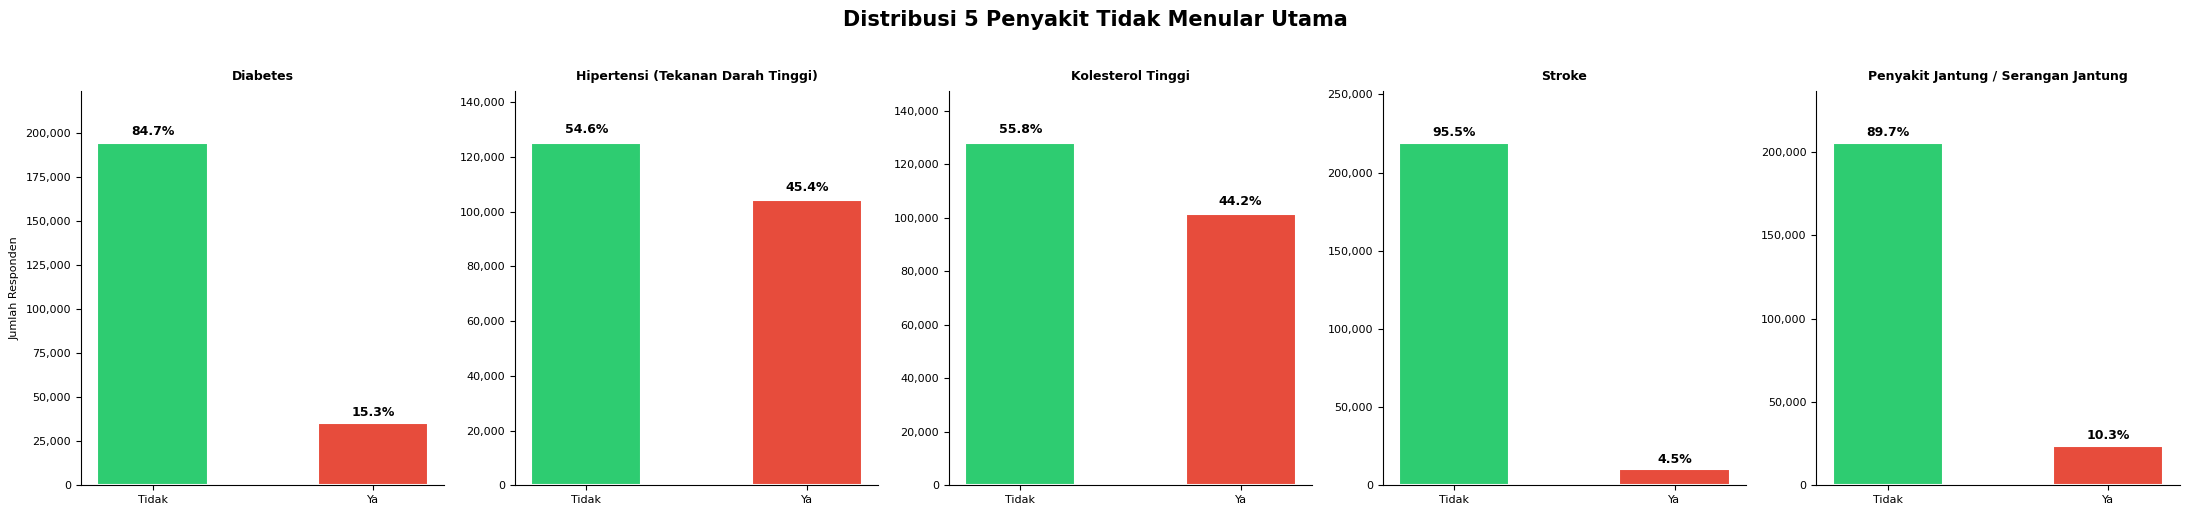

✓ Disimpan sebagai 'distribusi_penyakit.png'


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Distribusi 5 Penyakit Tidak Menular Utama',
             fontsize=15, fontweight='bold', y=1.02)

colors_disease = ['#2ECC71', '#E74C3C']

for i, (col, nama) in enumerate(kolom_penyakit.items()):
    ax = axes[i]
    counts = df_clean[col].value_counts().sort_index()
    bars = ax.bar(['Tidak', 'Ya'], counts.values,
                  color=colors_disease, edgecolor='white', linewidth=1.5, width=0.5)

    total = counts.sum()
    for bar, count in zip(bars, counts.values):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.01,
                f'{pct:.1f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    ax.set_title(nama, fontsize=9, fontweight='bold', pad=8)
    ax.set_ylabel('Jumlah Responden' if i == 0 else '', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.savefig('distribusi_penyakit.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Disimpan sebagai 'distribusi_penyakit.png'")

### Visualisasi — Heatmap Korelasi Faktor & Komorbiditas PTM

**Tujuan**: Menampilkan secara visual kekuatan korelasi antara faktor kesehatan dengan
setiap penyakit, serta hubungan antar penyakit (komorbiditas).

**Insight**:
- `GenHlth` memiliki korelasi positif terkuat dengan hampir semua PTM — persepsi
  kesehatan diri adalah sinyal awal yang sangat penting.
- `BMI` dan `Age` secara konsisten berkorelasi positif dengan semua penyakit —
  keduanya adalah faktor risiko universal.
- `HighBP` dan `HeartDiseaseorAttack` memiliki korelasi tertinggi antar penyakit —
  penderita hipertensi memiliki risiko signifikan untuk terkena penyakit jantung.
- Hampir semua pasangan penyakit berkorelasi positif → **komorbiditas yang nyata**,
  seseorang yang menderita satu PTM lebih rentan terhadap PTM lainnya.

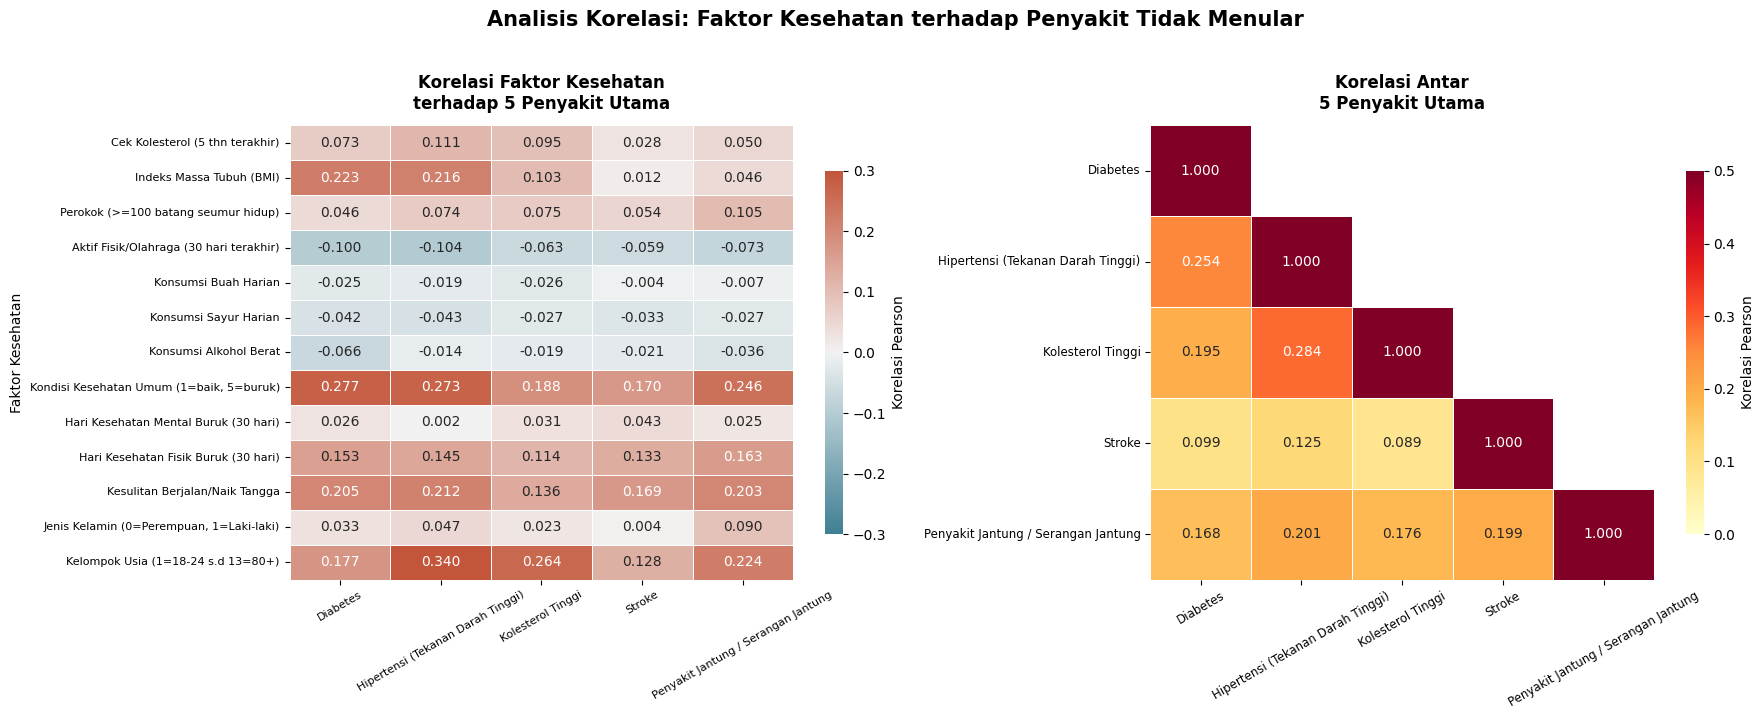

✓ Visualisasi disimpan sebagai 'heatmap_korelasi.png'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Analisis Korelasi: Faktor Kesehatan terhadap Penyakit Tidak Menular',
             fontsize=15, fontweight='bold', y=1.02)

cmap_diverging = sns.diverging_palette(220, 20, as_cmap=True)
cmap_sequential = sns.color_palette("YlOrRd", as_cmap=True)

ax1 = axes[0]

corr_matrix = pd.DataFrame({
    nama: df_clean[kolom_faktor].corrwith(df_clean[col])
    for col, nama in kolom_penyakit.items()
})
corr_matrix.index = [label_faktor[f] for f in kolom_faktor]

sns.heatmap(
    corr_matrix,
    ax=ax1,
    cmap=cmap_diverging,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    linecolor='white',
    vmin=-0.3, vmax=0.3,
    cbar_kws={'label': 'Korelasi Pearson', 'shrink': 0.8}
)
ax1.set_title('Korelasi Faktor Kesehatan\nterhadap 5 Penyakit Utama',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('')
ax1.set_ylabel('Faktor Kesehatan', fontsize=10)
ax1.tick_params(axis='x', rotation=30, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)

ax2 = axes[1]

corr_antar = df_clean[list(kolom_penyakit.keys())].corr()
corr_antar.index   = list(kolom_penyakit.values())
corr_antar.columns = list(kolom_penyakit.values())

mask = np.triu(np.ones_like(corr_antar, dtype=bool), k=1)

sns.heatmap(
    corr_antar,
    ax=ax2,
    mask=mask,
    cmap=cmap_sequential,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    linecolor='white',
    vmin=0, vmax=0.5,
    cbar_kws={'label': 'Korelasi Pearson', 'shrink': 0.8}
)
ax2.set_title('Korelasi Antar\n5 Penyakit Utama',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=30, labelsize=8.5)
ax2.tick_params(axis='y', rotation=0, labelsize=8.5)

plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Visualisasi disimpan sebagai 'heatmap_korelasi.png'")

### Visualisasi — Distribusi Faktor Numerikal: Sakit vs Tidak Sakit

**Tujuan**: Membandingkan distribusi lengkap setiap faktor numerikal antara kelompok
penderita dan bukan penderita untuk setiap PTM.

**Insight**:
- **BMI**: Distribusi kelompok "Sakit" bergeser ke nilai lebih tinggi untuk semua PTM,
  terutama Diabetes dan Hipertensi.
- **GenHlth**: Kelompok "Sakit" memiliki median lebih tinggi di semua penyakit,
  paling dramatis pada Stroke dan Penyakit Jantung.
- **Age**: Penderita PTM secara konsisten berasal dari kelompok usia lebih tua.
- **MentHlth & PhysHlth**: Variabilitas tinggi di kelompok "Sakit" — dampak PTM
  sangat bervariasi antar individu.

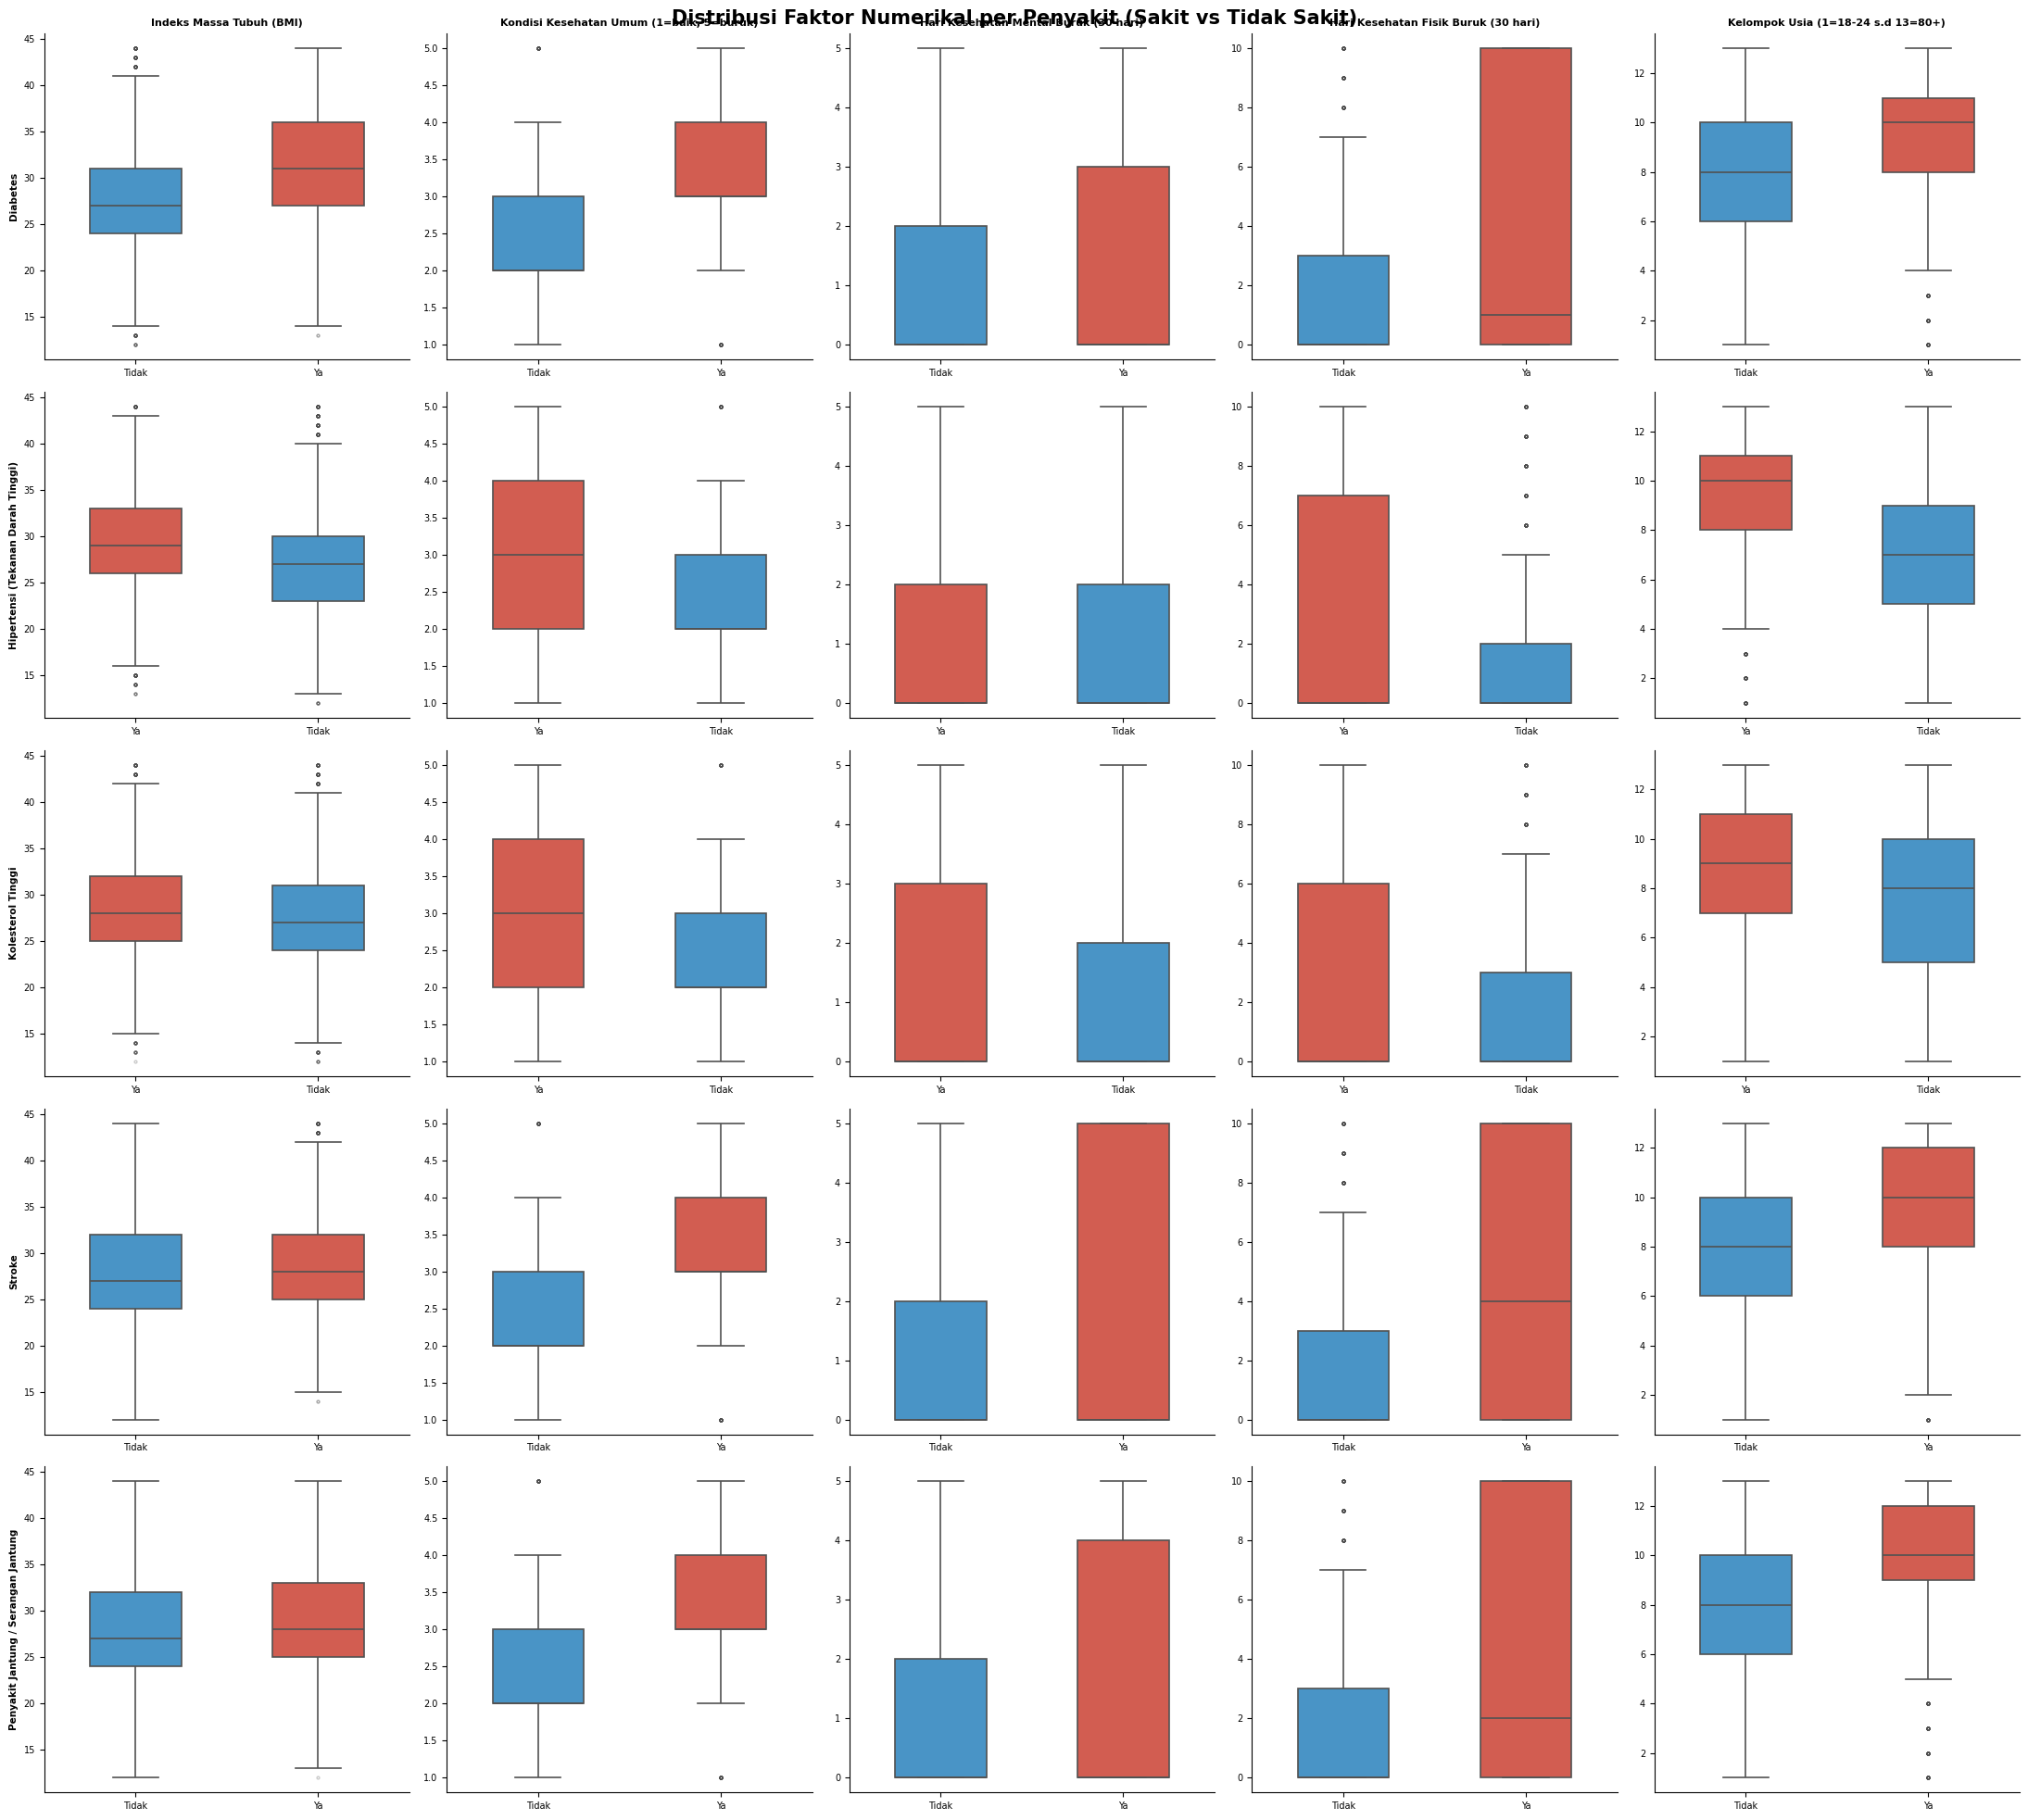

✓ Disimpan sebagai 'boxplot_numerikal.png'


In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(22, 20))
fig.suptitle('Distribusi Faktor Numerikal per Penyakit (Sakit vs Tidak Sakit)',
             fontsize=15, fontweight='bold')

palette_box = ['#3498DB', '#E74C3C']

for row_idx, (penyakit_col, penyakit_nama) in enumerate(kolom_penyakit.items()):
    for col_idx, faktor in enumerate(kolom_faktor_numerikal):
        ax = axes[row_idx][col_idx]

        data_plot = df_clean[[penyakit_col, faktor]].copy()
        data_plot[penyakit_col] = data_plot[penyakit_col].map({0.0: 'Tidak', 1.0: 'Ya'})

        sns.boxplot(
            data=data_plot,
            x=penyakit_col, y=faktor,
            palette={'Tidak': '#3498DB', 'Ya': '#E74C3C'},
            width=0.5, linewidth=1.2,
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
            ax=ax
        )

        if row_idx == 0:
            ax.set_title(label_faktor[faktor], fontsize=8, fontweight='bold', pad=6)
        else:
            ax.set_title('')

        if col_idx == 0:
            ax.set_ylabel(penyakit_nama, fontsize=7.5, fontweight='bold')
        else:
            ax.set_ylabel('')

        ax.set_xlabel('')
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('boxplot_numerikal.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Disimpan sebagai 'boxplot_numerikal.png'")

### Visualisasi — Proporsi Faktor Binary: Sakit vs Tidak Sakit

**Tujuan**: Membandingkan persentase responden yang memiliki setiap faktor binary
antara kelompok penderita dan bukan penderita.

**Insight**:
- **DiffWalk**: Perbedaan paling mencolok — penderita PTM jauh lebih banyak yang
  mengalami kesulitan berjalan, mencerminkan dampak fungsional penyakit.
- **PhysActivity**: Kelompok "Tidak Sakit" lebih banyak yang aktif olahraga —
  aktivitas fisik terbukti protektif terhadap PTM.
- **Smoker**: Proporsi perokok lebih tinggi pada kelompok "Sakit" di hampir semua
  penyakit — rokok adalah faktor risiko yang konsisten.
- **HvyAlcoholConsump**: Justru lebih rendah pada kelompok "Sakit" — kemungkinan
  karena penderita sudah mengurangi konsumsi alkohol setelah didiagnosis.

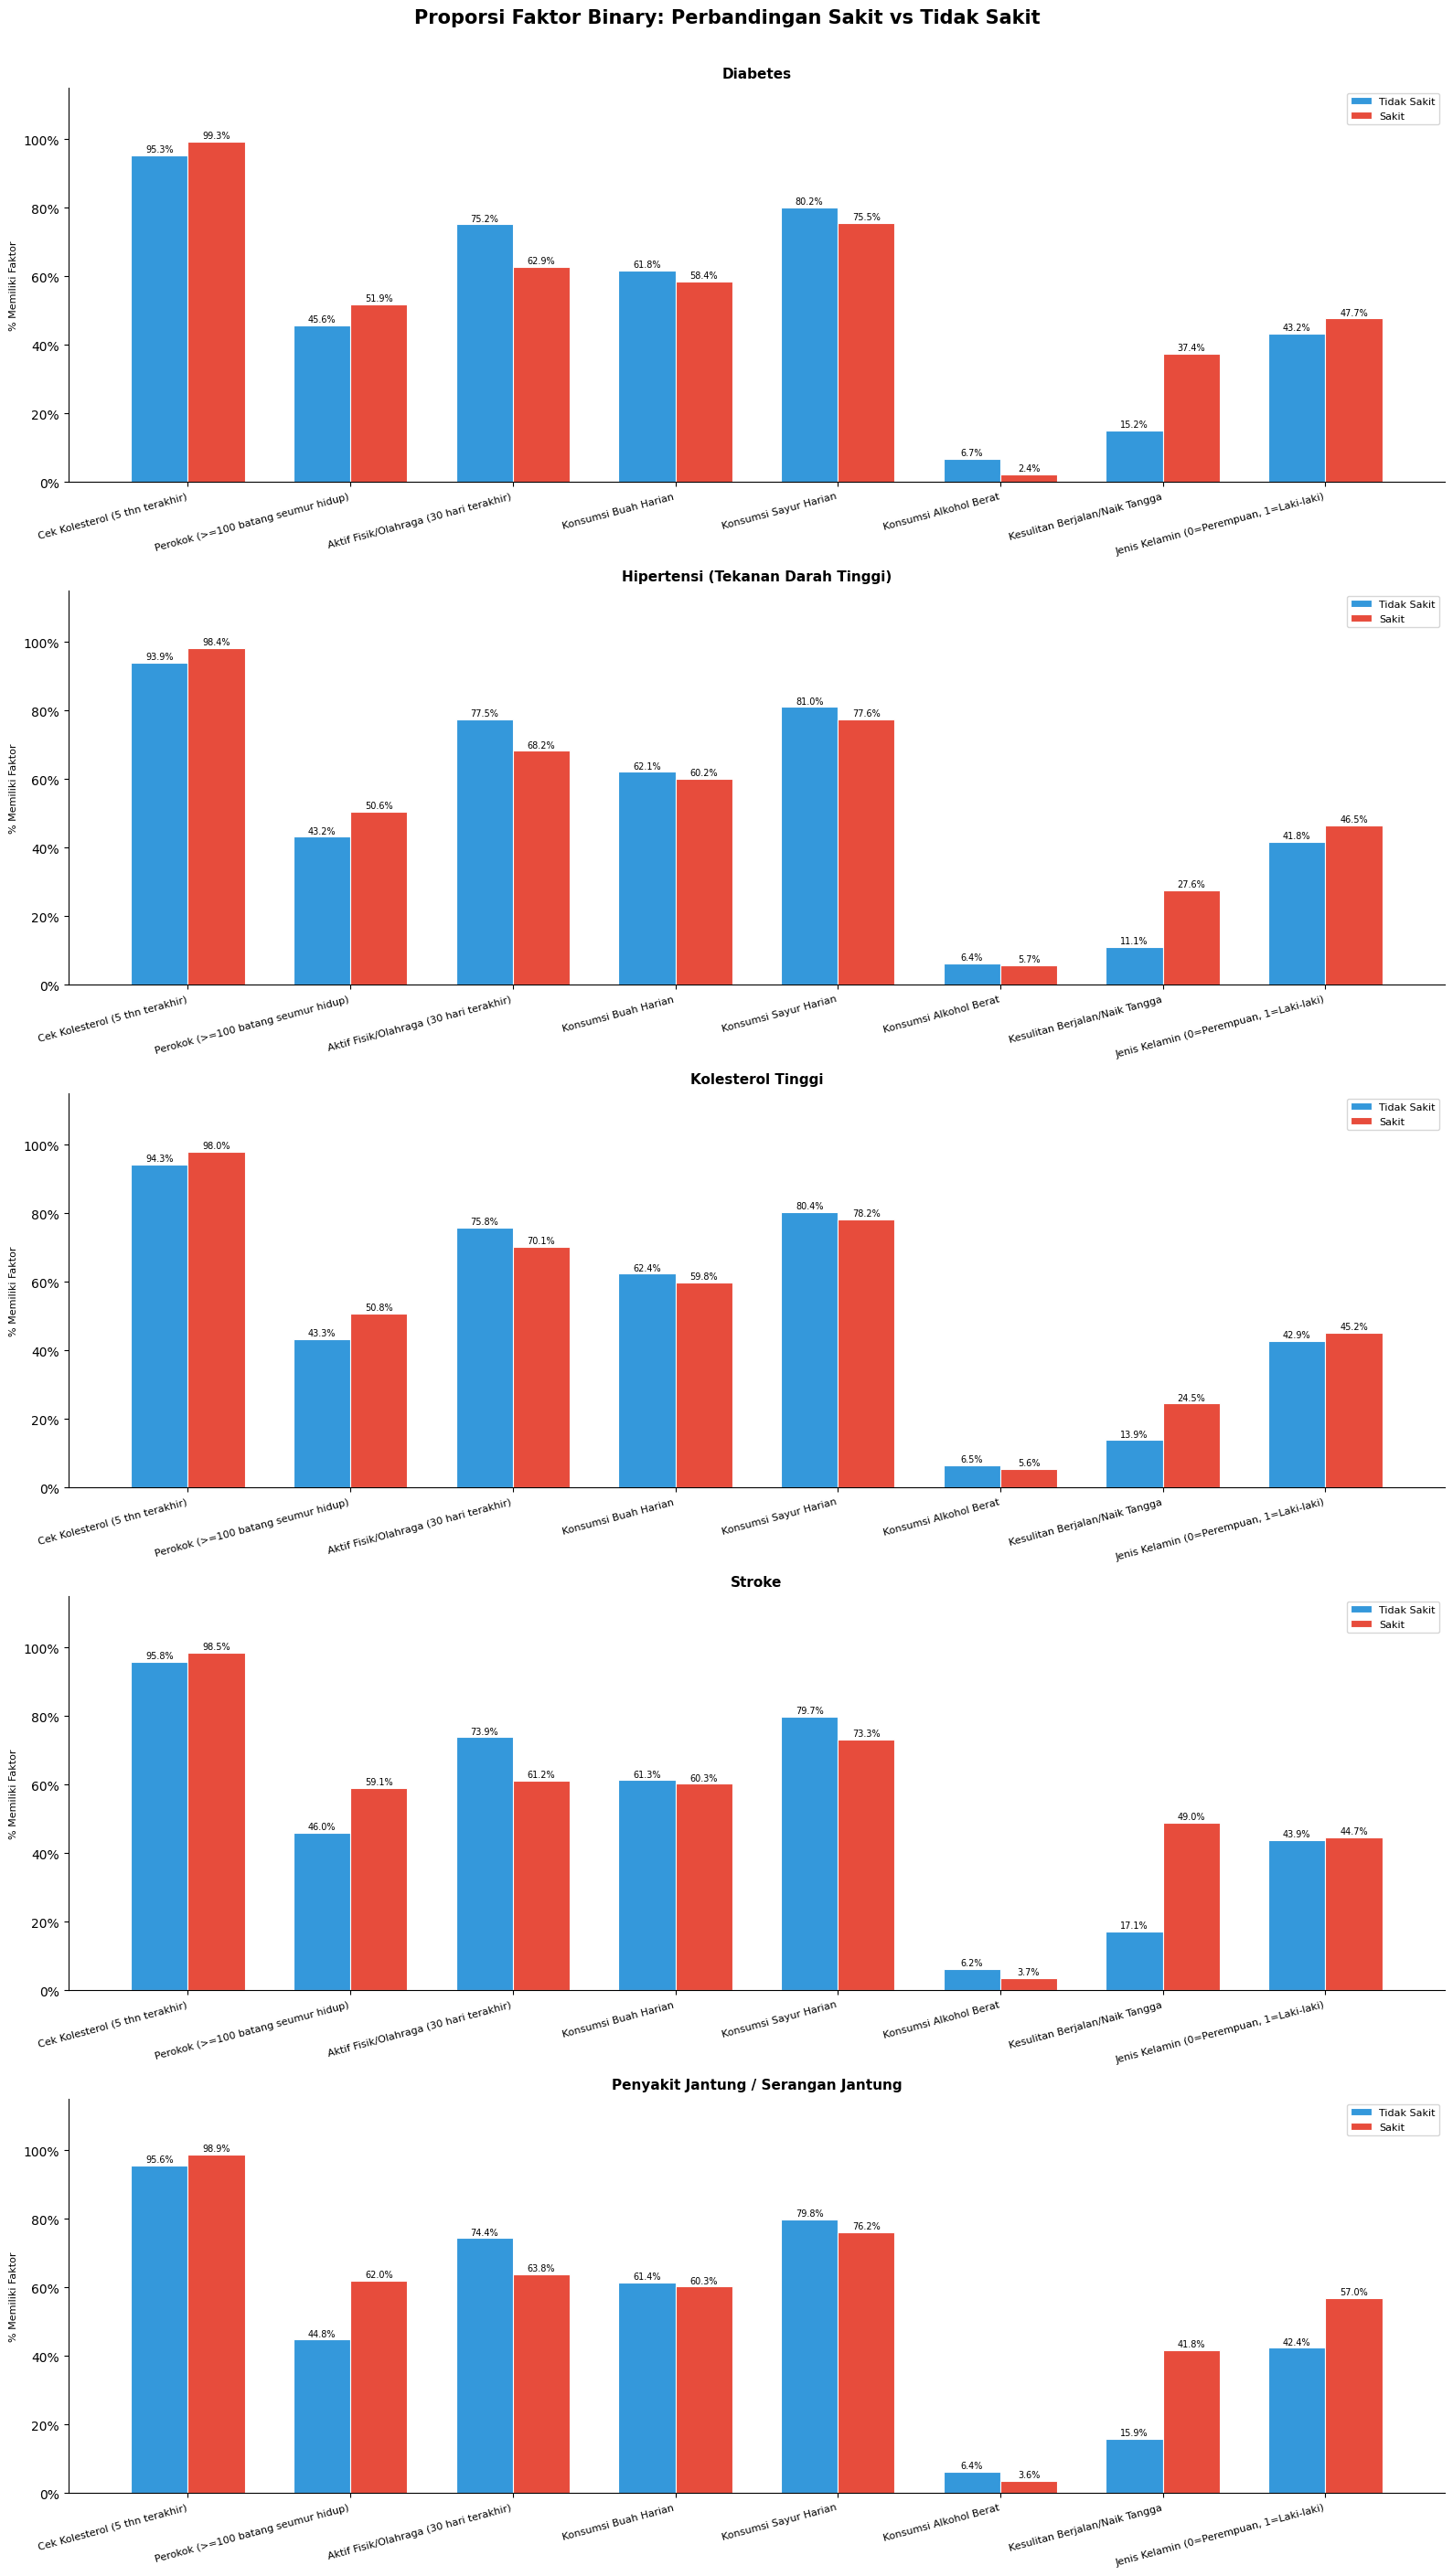

✓ Disimpan sebagai 'proporsi_binary.png'


In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(16, 28))
fig.suptitle('Proporsi Faktor Binary: Perbandingan Sakit vs Tidak Sakit',
             fontsize=15, fontweight='bold', y=1.005)

for row_idx, (penyakit_col, penyakit_nama) in enumerate(kolom_penyakit.items()):
    ax = axes[row_idx]

    props_tidak = []
    props_ya    = []
    labels      = []

    for faktor in kolom_faktor_binary:
        props = df_clean.groupby(penyakit_col)[faktor].mean() * 100
        props_tidak.append(props[0.0])
        props_ya.append(props[1.0])
        labels.append(label_faktor[faktor])

    x = np.arange(len(labels))
    width = 0.35

    bars1 = ax.bar(x - width/2, props_tidak, width, label='Tidak Sakit',
                   color='#3498DB', edgecolor='white', linewidth=0.8)
    bars2 = ax.bar(x + width/2, props_ya,    width, label='Sakit',
                   color='#E74C3C', edgecolor='white', linewidth=0.8)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7)

    ax.set_title(penyakit_nama, fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel('% Memiliki Faktor', fontsize=8)
    ax.set_ylim(0, 115)
    ax.legend(fontsize=8, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('proporsi_binary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Disimpan sebagai 'proporsi_binary.png'")

### Visualisasi — Persentase Penderita per Kelompok Usia

**Tujuan**: Menganalisis tren prevalensi setiap PTM berdasarkan kelompok usia untuk
mengidentifikasi titik kritis risiko penyakit mulai meningkat.

**Insight**:
- Semua PTM menunjukkan pola yang sama — prevalensi meningkat seiring bertambahnya
  usia, dengan percepatan mulai kelompok **usia 45-54 tahun**.
- **Stroke** memiliki lonjakan paling tajam di usia 65+ — skrining intensif penting
  untuk lansia.
- **Hipertensi** sudah terdeteksi sejak usia 35-44 tahun — perlu deteksi dini
  sejak usia produktif.
- Implikasi kebijakan: **program skrining PTM sebaiknya dimulai sejak usia 45 tahun**.

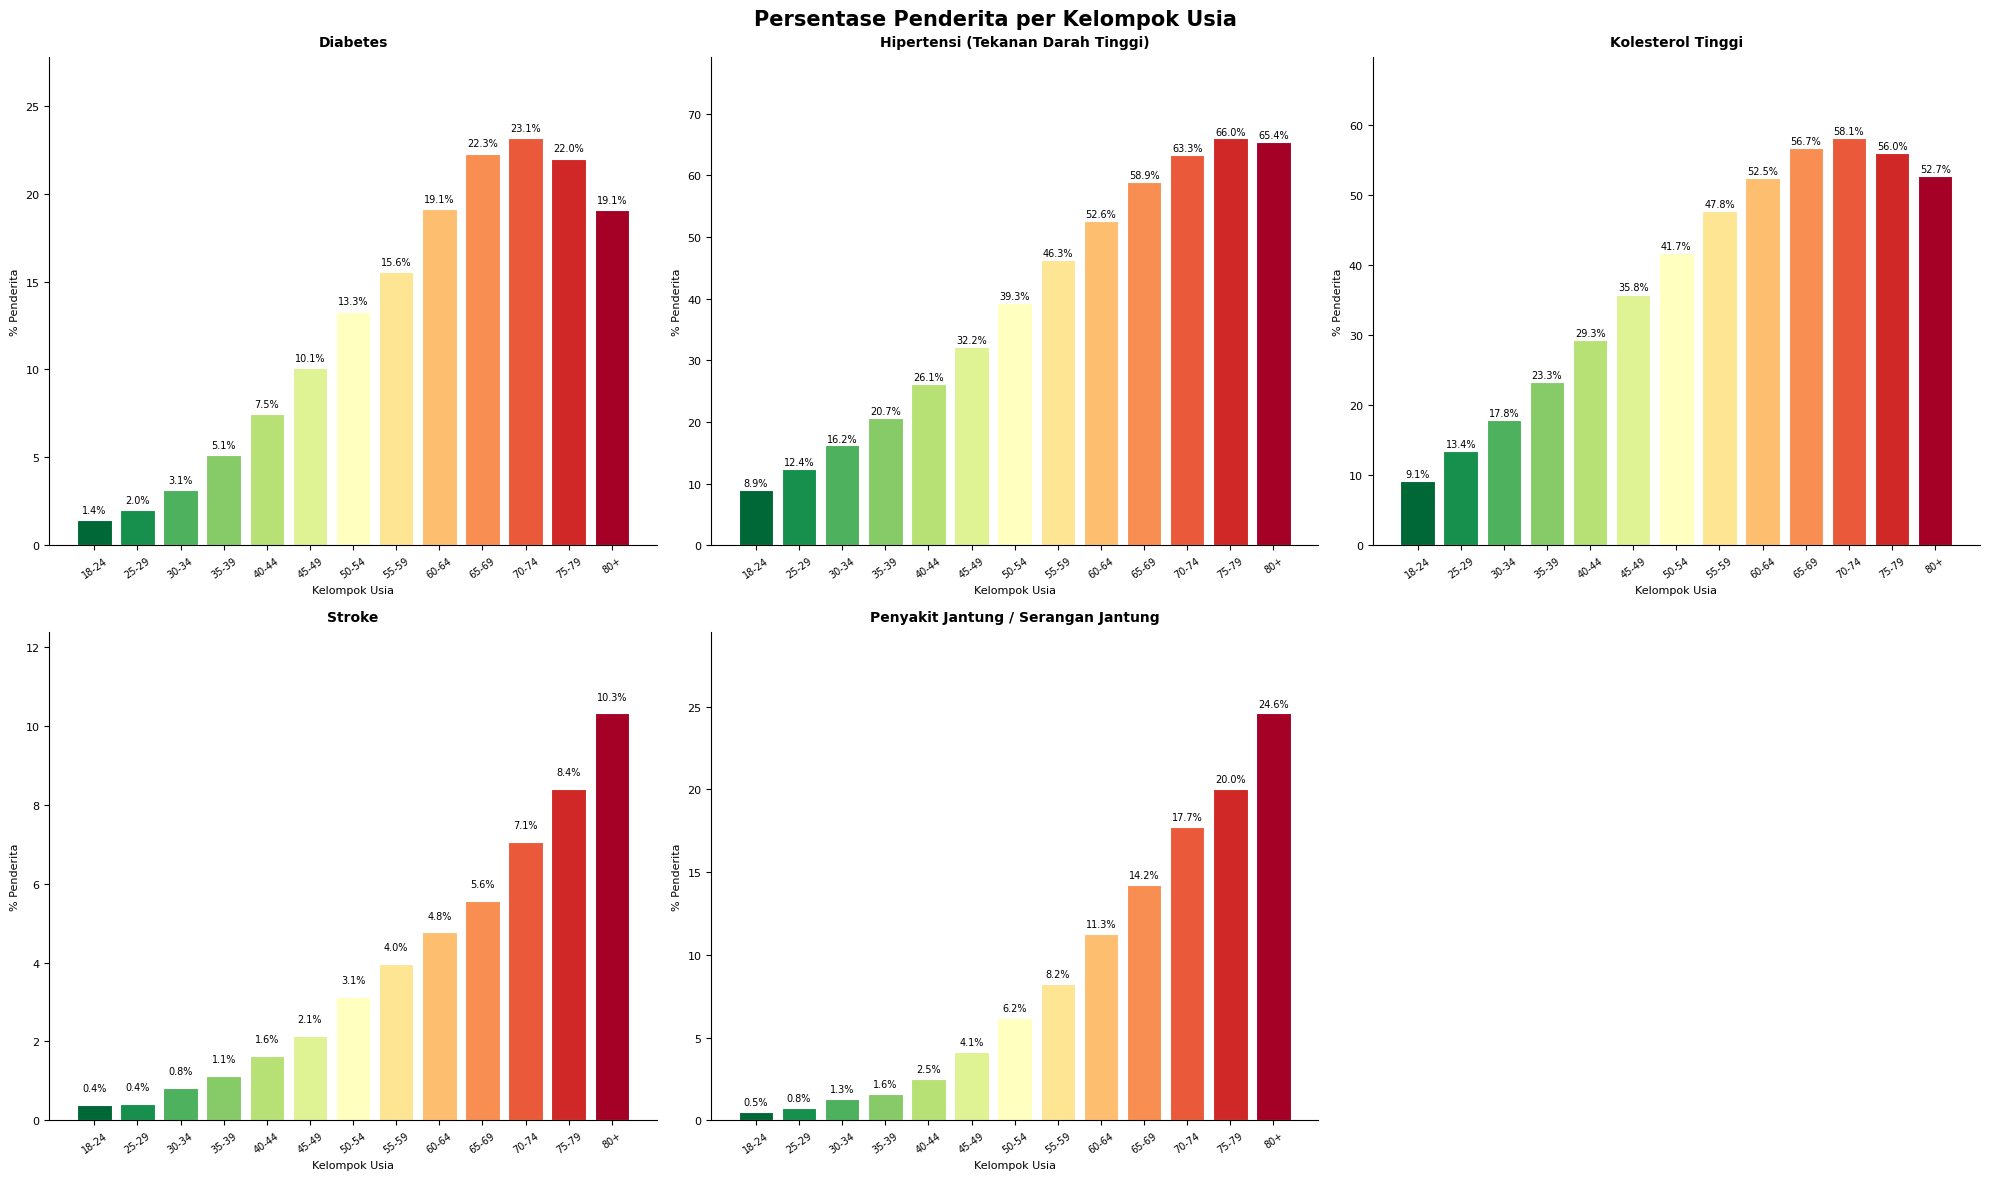

✓ Disimpan sebagai 'distribusi_usia.png'


In [ ]:
usia_label = {
    1:'18-24', 2:'25-29', 3:'30-34', 4:'35-39', 5:'40-44',
    6:'45-49', 7:'50-54', 8:'55-59', 9:'60-64', 10:'65-69',
    11:'70-74', 12:'75-79', 13:'80+'
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Persentase Penderita per Kelompok Usia',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

cmap_age = plt.cm.get_cmap('RdYlGn_r', 13)

for idx, (penyakit_col, penyakit_nama) in enumerate(kolom_penyakit.items()):
    ax = axes[idx]

    ct = df_clean.groupby(['Age', penyakit_col]).size().unstack(fill_value=0)
    ct.columns = ['Tidak', 'Ya']
    ct['Pct'] = ct['Ya'] / (ct['Ya'] + ct['Tidak']) * 100
    ct.index  = [usia_label[int(i)] for i in ct.index]

    colors = [cmap_age(i / 12) for i in range(len(ct))]
    bars = ax.bar(ct.index, ct['Pct'], color=colors,
                  edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, ct['Pct']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

    ax.set_title(penyakit_nama, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('Kelompok Usia', fontsize=8)
    ax.set_ylabel('% Penderita', fontsize=8)
    ax.tick_params(axis='x', rotation=35, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, ct['Pct'].max() * 1.2)

axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('distribusi_usia.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Disimpan sebagai 'distribusi_usia.png'")

### Visualisasi — Class Imbalance: Sebelum vs Sesudah SMOTE

**Tujuan**: Memverifikasi secara visual bahwa SMOTE berhasil menyeimbangkan kelas
pada setiap label PTM di data train.

**Insight**:
- **Sebelum SMOTE**: Ketidakseimbangan kelas sangat ekstrem, terutama Stroke (~95%
  kelas Tidak Sakit).
- **Sesudah SMOTE**: Distribusi menjadi seimbang sempurna (50:50) untuk semua label.
- Tanpa SMOTE, model akan memiliki akurasi tinggi namun **gagal mendeteksi kasus
  positif** yang justru lebih penting secara klinis.
- Data test **tidak di-SMOTE** agar evaluasi mencerminkan kondisi nyata di lapangan.

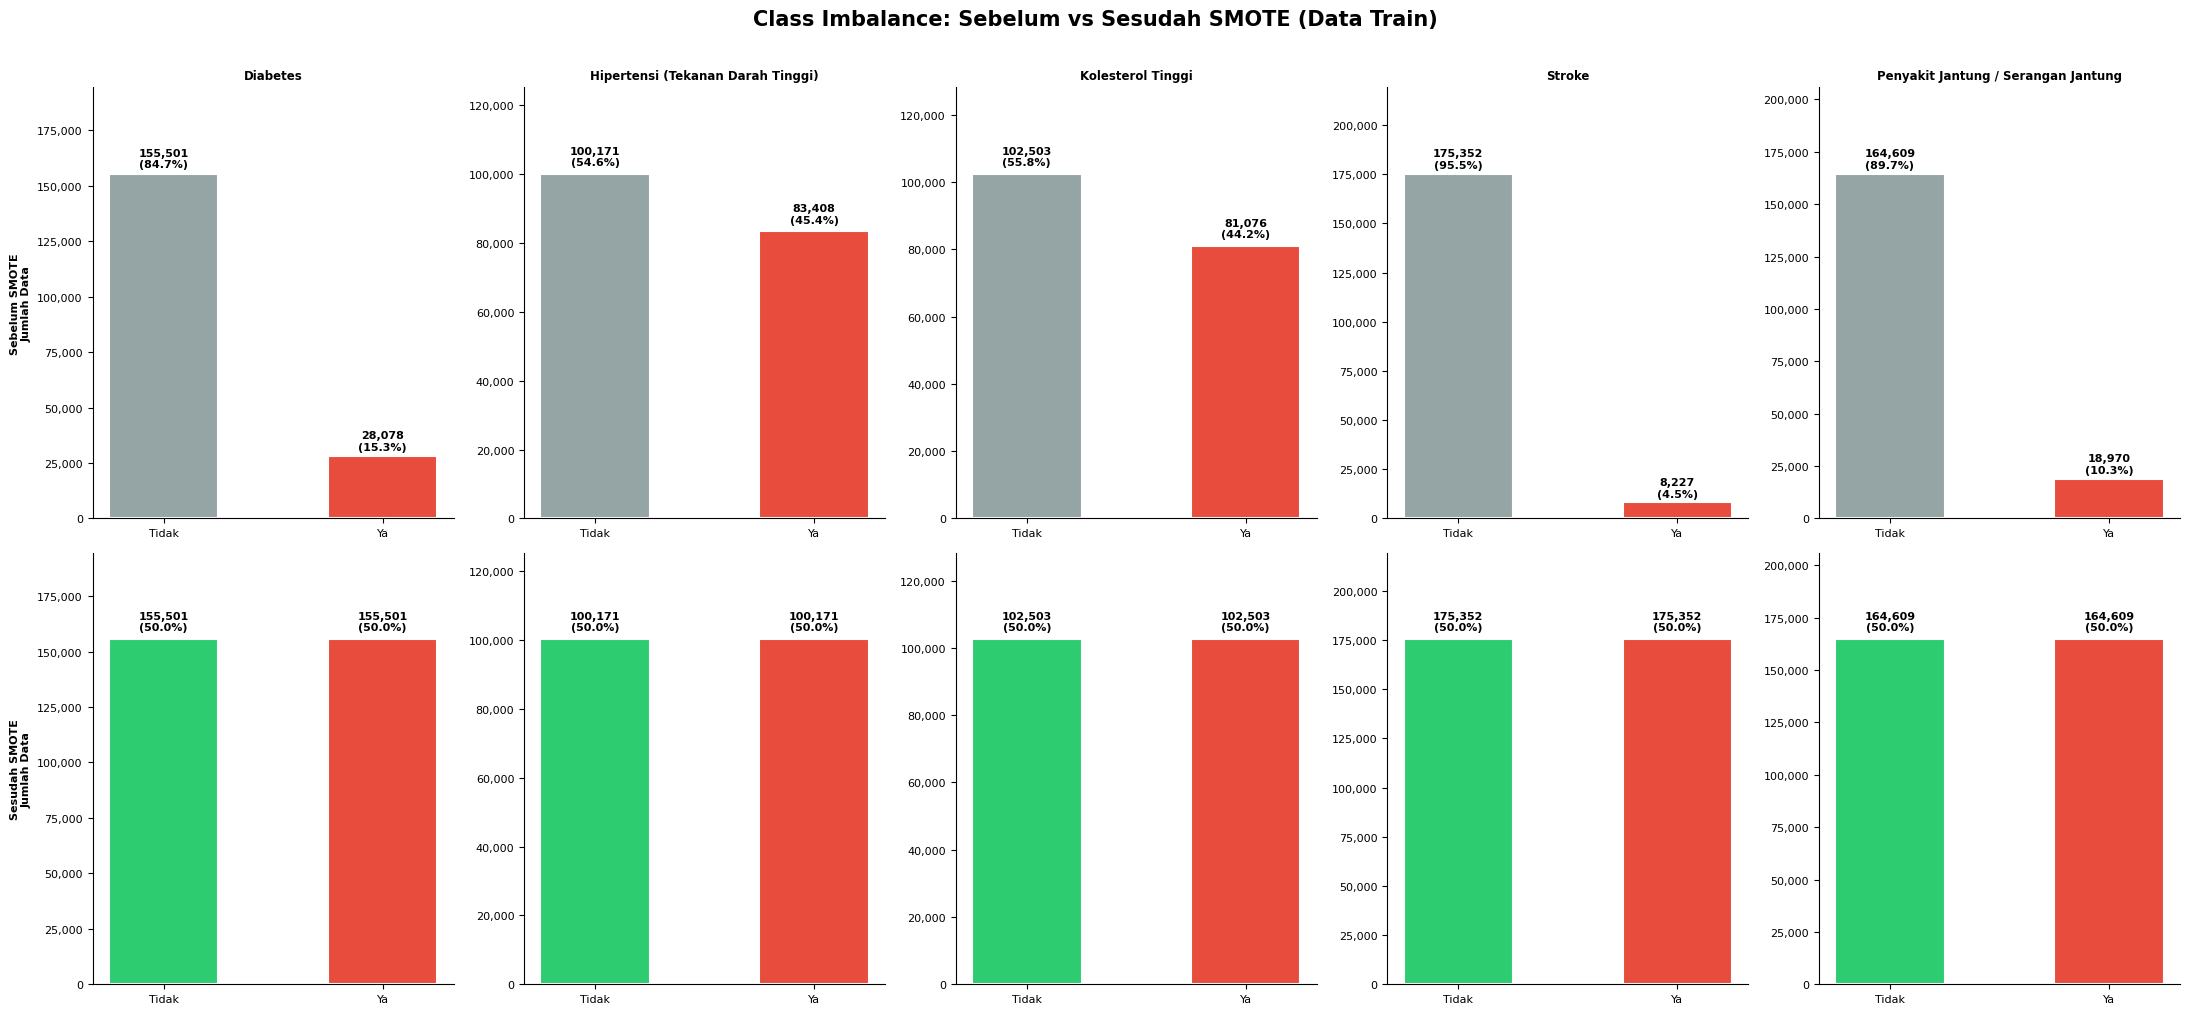

✓ Disimpan sebagai 'class_imbalance_smote.png'


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle('Class Imbalance: Sebelum vs Sesudah SMOTE (Data Train)',
             fontsize=15, fontweight='bold', y=1.01)

colors_smote = ['#95A5A6', '#E74C3C']

for col_idx, (penyakit_col, penyakit_nama) in enumerate(kolom_penyakit.items()):

    ax_before = axes[0][col_idx]
    before    = y_train[penyakit_col].value_counts().sort_index()
    bars = ax_before.bar(['Tidak', 'Ya'], before.values,
                         color=colors_smote, edgecolor='white', linewidth=1.5, width=0.5)
    total = before.sum()
    for bar, count in zip(bars, before.values):
        ax_before.text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + total * 0.01,
                       f'{count:,}\n({count/total*100:.1f}%)',
                       ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax_before.set_title(penyakit_nama, fontsize=8.5, fontweight='bold', pad=6)
    ax_before.set_ylabel('Jumlah' if col_idx == 0 else '', fontsize=8)
    ax_before.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_before.tick_params(labelsize=8)
    ax_before.spines[['top', 'right']].set_visible(False)
    ax_before.set_ylim(0, max(before.values) * 1.25)
    if col_idx == 0:
        ax_before.set_ylabel('Sebelum SMOTE\nJumlah Data', fontsize=8, fontweight='bold')

    ax_after = axes[1][col_idx]
    X_res, y_res = hasil_smote[penyakit_col]
    after = pd.Series(y_res).value_counts().sort_index()
    bars2 = ax_after.bar(['Tidak', 'Ya'], after.values,
                         color=['#2ECC71', '#E74C3C'], edgecolor='white', linewidth=1.5, width=0.5)
    total2 = after.sum()
    for bar, count in zip(bars2, after.values):
        ax_after.text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + total2 * 0.01,
                      f'{count:,}\n({count/total2*100:.1f}%)',
                      ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax_after.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_after.tick_params(labelsize=8)
    ax_after.spines[['top', 'right']].set_visible(False)
    ax_after.set_ylim(0, max(after.values) * 1.25)
    if col_idx == 0:
        ax_after.set_ylabel('Sesudah SMOTE\nJumlah Data', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('class_imbalance_smote.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✓ Disimpan sebagai 'class_imbalance_smote.png'")